# Atividade 2 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 10 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural multilayer perceptron para distinguir atributos que definem a renda média de uma pessoa adulta a partir do _UCI Adult Income Dataset_

## Material de Referência para Estudo

- https://docs.pytorch.org/docs/stable/nn.html
- https://machinelearningmastery.com/develop-your-first-neural-network-with-pytorch-step-by-step/
- https://sebastianraschka.com/teaching/pytorch-1h/#7-a-typical-training-loop



## Prazos importantes

- Data de entrega: 16/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Trios

#### ALUNOS
Caio Jorge da Cunha Queiroz - 2315310028
Lucas Maciel Gomes - 2315310014
Izabella de Lima Catrinck -

# Abertura e Análise Exploratória do Dataset

- A tarefa a ser considerada é uma tarefa de classificação binária, cujo objetivo é determinar se a renda média de uma pessoa adulta excedará os US $50,000 por ano.
- O dataset em questão pode ser obtido aqui: https://archive.ics.uci.edu/dataset/2/adult
- Faça uma pré-seleção dos exemplos, conforme sugerido pelos autores: (AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0))
- Exclua todas as linhas com dados faltantes
- Quantos exemplos viáveis há no dataset?
- Preparação de atributos: todos os atributos categóricos devem ser codificados com One-Hot Encoding
- O dataset é balanceado?

In [3]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    balanced_accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# Reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)

In [4]:
## Carregamento do dataset
colunas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Leitura do arquivo de treino
df_train = pd.read_csv('adult/adult.data', names=colunas, skipinitialspace=True)

# Leitura do arquivo de teste
df_test = pd.read_csv('adult/adult.test', names=colunas, skipinitialspace=True, skiprows=1)

# Prevenção de erro na leitura do rótulo
df_test['income'] = df_test['income'].str.rstrip('.')

df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Total de exemplos (treino + teste): {len(df)}")
print(f"Dimensões: {df.shape}")
df.head()

Total de exemplos (treino + teste): 48842
Dimensões: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
## Análise exploratória dos dados - tipagem e valores faltantes
print("Tipos de dados:")
print(df.dtypes)

print("\nValores faltantes ('?') por coluna:")
for col in colunas:
    n = (df[col] == '?').sum()
    if n > 0:
        print(f"  {col}: {n} ({n / len(df) * 100:.2f}%)")

Tipos de dados:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

Valores faltantes ('?') por coluna:
  workclass: 2799 (5.73%)
  occupation: 2809 (5.75%)
  native-country: 857 (1.75%)


In [6]:
## Pré-seleção dos exemplos - filtro dos autores
## ((AAGE > 16) && (AGI > 100) && (AFNLWGT > 1) && (HRSWK > 0))

filtro = (
        (df['age'] > 16) &
        (df['capital-gain'] > 100) &
        (df['fnlwgt'] > 1) &
        (df['hours-per-week'] > 0)
)

df_filtrado = df[filtro].copy()

print(f"Exemplos antes do filtro:  {len(df)}")
print(f"Exemplos após o filtro:    {len(df_filtrado)}")
print(f"Exemplos removidos:        {len(df) - len(df_filtrado)}")

Exemplos antes do filtro:  48842
Exemplos após o filtro:    4035
Exemplos removidos:        44807


In [7]:
## Remoção das linhas com dados faltantes ('?')
n_antes = len(df_filtrado)

df_limpo = df_filtrado.replace('?', np.nan).dropna().reset_index(drop=True)

print(f"Exemplos antes da remoção: {n_antes}")
print(f"Exemplos após remoção:     {len(df_limpo)}")
print(f"Linhas removidas:          {n_antes - len(df_limpo)}")

Exemplos antes da remoção: 4035
Exemplos após remoção:     3790
Linhas removidas:          245


Distribuição do atributo-alvo:
  >50K: 2375 exemplos (62.66%)
  <=50K: 1415 exemplos (37.34%)


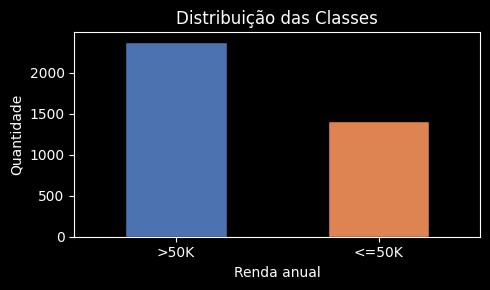

In [8]:
## Verificação do balanceamento
## Checagem de proporção do atributo alvo income

# Distribuição das classes
contagem = df_limpo['income'].value_counts()
proporcao = df_limpo['income'].value_counts(normalize=True) * 100

print("Distribuição do atributo-alvo:")
for classe in contagem.index:
    print(f"  {classe}: {contagem[classe]} exemplos ({proporcao[classe]:.2f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
contagem.plot(kind='bar', color=['#4C72B0', '#DD8452'], edgecolor='black', ax=ax)
ax.set_title('Distribuição das Classes')
ax.set_xlabel('Renda anual')
ax.set_ylabel('Quantidade')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [9]:
## Padronização dos atributos categóricos via One-Hot Coding
## Ideia principal é que colunas categóricas obtenham colunas binárias para cada categoria possível
## Nesse caso, o atributo de income será codificado separadamente como <50k -> 0, >50k -> 1

cat_cols = df_limpo.select_dtypes(include=['object', 'string']).columns.tolist()
cat_cols.remove('income')
print(f"Colunas categóricas: {cat_cols}")

# Codificação do atributo-alvo
df_limpo['income'] = df_limpo['income'].map({'<=50K': 0, '>50K': 1}).astype(int)

# Aplicação do One-Hot Encoding
df_encoded = pd.get_dummies(df_limpo, columns=cat_cols, dtype=int)

print(f"\nDimensões antes do encoding:  {df_limpo.shape}")
print(f"Dimensões após o encoding:    {df_encoded.shape}")
print(f"Número de atributos preditores: {df_encoded.shape[1] - 1}")
df_encoded.head()

Colunas categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Dimensões antes do encoding:  (3790, 15)
Dimensões após o encoding:    (3790, 102)
Número de atributos preditores: 101


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Private,...,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,31,45781,14,14084,0,50,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,42,159449,13,5178,0,40,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,30,188146,9,5013,0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,30,59496,13,2407,0,40,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


### Respostas da primeira seção - Abertura e Análise Exploratória

**Quantos exemplos viáveis há no dataset?**

Partimos de um total de 48.842 exemplos (32.561 do arquivo de treino + 16.281 do arquivo de teste). Após a aplicação do filtro dos autores `(age > 16) && (capital-gain > 100) && (fnlwgt > 1) && (hours-per-week > 0)`, restaram 4.035 exemplos. A maior redução foi causada pelo critério `capital-gain > 100`, já que a grande maioria das pessoas no censo possui ganho de capital igual a zero. Em seguida, removemos 245 linhas que continham valores faltantes (`'?'`), concentrados nas colunas `workclass`, `occupation` e `native-country`. Ao final, obtivemos 3.790 exemplos viáveis.

**Preparação dos atributos**

Das 15 colunas originais, 8 são categóricas (`workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`). Após aplicarmos o One-Hot Encoding nessas colunas e codificarmos o atributo-alvo como binário (<=50K → 0, >50K → 1), o dataset passou de 15 colunas para 102 colunas, resultando em 101 atributos preditores.

**O dataset é balanceado?**

Não, o dataset não é balanceado. A distribuição das classes ficou:

| Classe | Quantidade | Proporção |
|:-:|:-:|:-:|
| >50K | 2.375 | 62,66% |
| ≤50K | 1.415 | 37,34% |

É interessante notar que essa proporção é o inverso do que ocorre no dataset completo (onde ~76% é ≤50K). Essa inversão acontece porque o filtro `capital-gain > 100` seleciona pessoas com ganhos de capital significativos.

## Preparação dos exemplos para treino e teste

- Separe os atributos preditores do atributo-alvo
- Faça uma partição do tipo holdout 70/30 de forma aleatória, use seed = 42
- Codifique os exemplos em tensores pytorch

## Rede MLP de Camada Única

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

### Avaliação da MLP de Camada Única

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da rede perante essa tarefa?

## Rede MLP com duas camadas ocultas

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta 1: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada oculta 2: 50 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

### Avaliação da MLP com Duas Camadas Ocultas

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da nova rede perante essa tarefa? Houve melhora?

## Sua rede MLP

- Proponha uma rede neural multilayer perceptron no Pytorch com uma ou duas camadas ocultas e número de neurônios conforme sua livre escolha, levando em conta razoabilidade,  tempo de execução no hardware disponível e prazo de entrega da atividade
- Hiperparâmetros:
   - Modifique-os como desejar
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

### Avaliação da sua rede MLP

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste

## Análise Comparativa Final

Construa uma tabela (pacote prettytable) com as métricas de desempenho das três redes propostas na partição de testes e justifique, com base em argumentos de performance, eficiência e aderência ao problema, qual delas possivelmente obteve melhor desempenho na tarefa.